# Deep Learning and Natural Language Processing 
---

**Empirical Methods in Economics and Business** 

Zhiyuan Chen 

Renmin Business School 

June 2025


## Roadmap 

  
 #### Introduction to Neural Networks 
  
 #### Backward Propagation
  
 #### Training Neural Networks using `PyTorch`

## Human Neurons 
---
<div align="center">
<img src="images/neurons.jpg" width="380"/>
</div>

* **Soma (胞体) (cell body)** – 神经元的核心部分，负责接收和处理来自其他神经元的信号。

* **Axon (轴突)** – 将胞体产生的信号传输到其他神经元的“电缆”，起到输出作用。

* **Myelin Sheath (髓鞘)** –  包裹在轴突外的绝缘层，有助于加快信号传递速度并提高传输效率。

## A View of a Neuron from A Binary Logistic Regression 
---
<div align="center">
<img src="images/a_single_neuron.png" width="350"/>
</div>

A single neuron can be viewed as a binary [**logistic regression model**](https://en.wikipedia.org/wiki/Logistic_regression):
\begin{aligned}
 \hat{y} = h_{w,b}(x) =& f(w^\top x + b) \\
f(z) =& \frac{1}{1 + e^{-z}} 
\end{aligned}
* $x$: **inputs**; $w$: **weights**; $b$:**bias**; $h(\cdot)$: **hidden layer**; $f(\cdot)$: **activation function**; $\hat{y}$: **output**.

### Neural Network = Running Multiple Logistic Regression Models Together 
---
We can feed them into another logistic regression, yielding a **two-layer neural network**:

<div align="center">
<img src="images/neural_network_two_layers.png" width="400"/>
</div>

> The **final loss function** (measures the prediction performance) determines what the *intermediate hidden variables* should be. 

We can add more layers to the network, yielding a **multi-layer neural network**:
<div align="center">
<img src="images/neural-network-architecture.png" width="450"/>
</div>

> This multi-layer structure allows to re-represent and compose the data multiple times and to learn a **highly non-linear classifier** in terms of the original inputs. 

### Matrix Representation of Neural Networks
---
We can represent the above two-layer neural network in a matrix form:
\begin{aligned}
\begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ 1 \end{bmatrix} \longrightarrow \begin{bmatrix} f(w_{11} x_1 + w_{12}x_2+w_{13}x_3 + b_1 ) \\ f(w_{21} x_1 + w_{22} x_2 + w_{23} x_3+b_2) \\ f(w_{31} x_1 + w_{32} x_2 + w_{33} x_3+b_3) \end{bmatrix} 
= \begin{bmatrix} a_1 \\ a_2   \\ a_3  \end{bmatrix}
\end{aligned}

\begin{aligned}
\boldsymbol{z} = & \mathbf{W}^\top \boldsymbol{x} + \boldsymbol{b} \\
\boldsymbol{a} = & f(\boldsymbol{z}) = f(\mathbf{W}^\top \boldsymbol{x} + \boldsymbol{b})
\end{aligned}
The whole **architecture** can be represented as:
\begin{aligned}
\text{layer 1}&: \boldsymbol{h}^{(1)} = f^{(1)}(\mathbf{W}^{(1)\top} \boldsymbol{x} + \boldsymbol{b}^{(1)}) \\
\text{layer 2}&: \boldsymbol{h}^{(2)} = f^{(2)}(\mathbf{W}^{(2)\top} \boldsymbol{h}^{(1)} + \boldsymbol{b}^{(2)}) \\
\cdots & \\
\text{layer L}&: \boldsymbol{h}^{(L)} = f^{(L)}(\mathbf{W}^{(L)\top} \boldsymbol{h}^{(L-1)} + \boldsymbol{b}^{(L)}) 
\end{aligned}

### Activation Functions 
---

| Activation Function | Formula                            | Output Range     | Key Properties                                      |
|---------------------|------------------------------------|------------------|-----------------------------------------------------|
| Sigmoid/Logistic             | $σ(x) = \frac{1}{1 + e^{-x}}$            | $(0, 1)$           | Smooth, squashes input, causes vanishing gradients |
| Tanh                | $\tanh(x) =\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$         | Zero-centered, still suffers vanishing gradient    |
| ReLU (Rectified Linear Unit)               | $\max(0, x)$                | $[0, ∞) $          | Sparse activation, efficient, may cause dead units |
| Leaky ReLU          | $\small \max(αx, x), α ≈ 0.01$    | $(-∞, ∞) $         | Fixes dead neuron issue of ReLU                    |
| ELU                 | $x ≥ 0 → x, \text{else } α(e^x − 1)$         | $(-α, ∞)$          | Smooth, avoids dead neurons, better convergence    |
| Softmax             | $σ(x_i) = e^{x_i} / Σ e^{x_j}$          | $\small (0, 1),\,\sum_i σ(x_i) = 1$  | Used in output layer for classification            |
| [Swish](https://arxiv.org/abs/1710.05941)               | $x \cdot \text{sigmoid}(x)$                     | $(-∞, ∞)  $        | Smooth, non-monotonic, good empirical performance  |
| [GELU (Gaussian Error Linear Units)](https://arxiv.org/abs/1606.08415)                | $\small x \cdot Φ(x), Φ(\cdot)\sim N(0,1)$  | $(-∞, ∞)   $       | Used in transformers, smooth & stochastic-like     |

#### Plots of Activation Functions

<div align="center">
<img src="images/activation_functions.png" width="600"/>
</div>

* **Sigmoid** and **Tanh** are still used is some cases 
  
* **ReLU** is the most widely used activation function in deep learning, especially in hidden layers
  * Trains quickly and performs well due to **good gradient backflow**
  * **ReLU** has a "dead zone", which motivates **GELUE** and **Swish** as alternatives. 


### The "Magic": Aggregating Activation Function into Nonlinear Functions
---
* Fundamentally, neural networks do **function approximation**, e.g., non-linear regression/classification 
  
  *  Without non-linearities, deep neural networks can’t do anything more than a linear transform
  
  *  Extra layers could just be compiled down into **a single linear transform**
  
  * With more layers with non-linearities, neural networks can approximate **any complex function**!
 <div align="center"> 
<img src="images/non-linear_classifier.png" width="350"/>
</div>

## Training Neural Networks
---
### 1. Improved Gradient Descent Methods

### 2. Backpropagation 

### 3. Introduction to `PyTorch`

### 1. Improved Gradient Descent Methods
---
#### (1) SGD and Mini-Batch Gradient Descent
#### (2) Adaptive Moment Estimation (Adam)

#### (1) Stochastic Gradient Descent (SGD) and Mini-batch Gradient Descent
---
* **Goal of Training**: Find the weights $\theta \bf{W}$ to minimize the *loss function*:
  $$\bm{W}^* = \argmin_{\bf{W}} J{(\bm{W})}$$

* The **gradient descent** algorithm finds the solution using the following updating rule: 
  $$\bm{W}^{(k+1)} = \bm{W}^{(k)} - \underbrace{\color{blue}\alpha}_{\text{learning rate}} \cdot \underbrace{\color{red}\nabla_{\bm{W}} J{(\bm{W}^{(k)})}}_{\text{Gradient}}$$

* **Problem**: The dimension of $\bm{W}$ is usually large in neural networks (in billions!), computing $\nabla_{\bm{W}} J{(\bm{W}^{(k)})}$ over the entire sample is expensive. 

> **Stochastic Gradient Descent**: Use **only one randomly chosen sample** to compute the gradient, instead of using the entire dataset. 
> * **Cons**: High variance in updates → noisy and may not converge smoothly.

> **Mini-batch Gradient Descent**: Use **a small batch of samples** to compute the gradient, which is a compromise between **batch gradient descent** and **stochastic gradient descent**.
> * **Pros**: Smoother convergence than SGD, faster than full sample gradient descent.

#### (2) Adaptive Moment Estimation (Adam)
---
* [**Adam**](https://arxiv.org/abs/1412.6980) is an extremely popular optimizer and possibly the most widely used in deep learning. It works well with **SGD** variants/mini-batch schemes [(Intuition)](https://medium.com/@weidagang/demystifying-the-adam-optimizer-in-machine-learning-4401d162cb9e)

* **Adam** combines the benefits of two other extensions of SGD:
  
  * **Momentum**: Accelerates SGD by accumulating past gradients to smooth out updates.
  
  * **RMSProp**: Adapts the learning rate for each parameter based on the magnitude of recent gradients.

<div align="center">
<b> Adam Algorithm </b> <br>
<img src="images/Adam_algorithm.png" width="400"/>
</div>

> `parameter choice`: $\alpha=0.001$, $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# Define a simple loss function
def loss(x):
  return (x - 2)**2
# Define Adam optimizer
def adam_update(param, grad, learning_rate, beta1, beta2, t):
  """adam algorithm update step.
  Args: t - current iteration number
        beta1 - decay rate for the first moment
        beta2 - decay rate for the second moment
        v - exponentially moving average of the squared gradients
        epsilon - small constant to avoid division by zero"""
        
  m = beta1 * m_prev + (1 - beta1) * grad
  v = beta2 * v_prev + (1 - beta2) * grad**2
  # Correct the bias in the first moment caused by initialization at origin.
  m_hat = m / (1 - beta1**(t + 1))
  # Correct the bias in the second moment caused by initialization at origin.
  v_hat = v / (1 - beta2**(t + 1))
  # Update parameters.
  param -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
  # Return the updated parameters, as well as the first and second moment estimates.
  return param, m, v

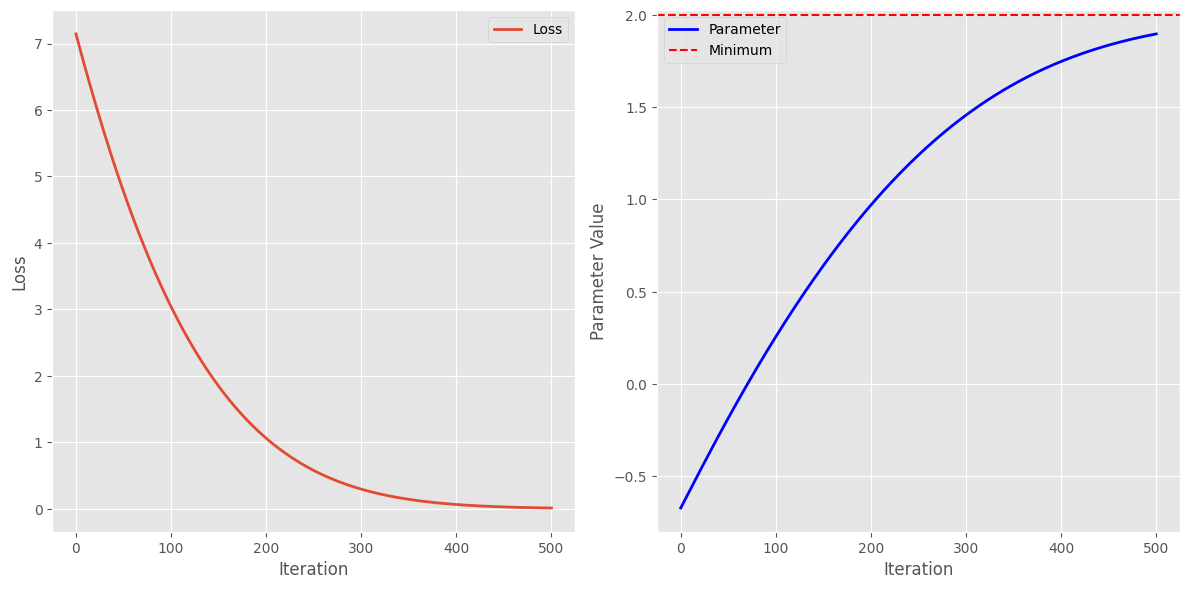

In [ ]:
# Initialize parameters and optimizer state
param = np.random.randn()
m_prev = np.zeros_like(param)
v_prev = np.zeros_like(param)
learning_rate = 0.01 #experiment with different learning rates 
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
# Track parameter values and loss over time
param_history = [param]
loss_history = [loss(param)]
# Training loop
epochs = 500
for t in range(epochs):
  # Calculate gradient
  grad = 2 * (param - 2)
  # Update parameter and optimizer state
  param, m_prev, v_prev = adam_update(param, grad, learning_rate, beta1, beta2, t)
  # Track parameter and loss
  param_history.append(param)
  loss_history.append(loss(param))
# Plot results
# Plot loss over time
plt.subplot(1,2,1)
plt.plot(range(len(loss_history)),loss_history, lw=2, label="Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
# Plot parameter trajectory
plt.subplot(1,2,2)
plt.plot(range(len(param_history)), param_history, color='blue', lw=2, label="Parameter")
plt.axhline(2, color="red", linestyle="--", label="Minimum")
plt.xlabel("Iteration")
plt.ylabel("Parameter Value")
plt.legend()
plt.tight_layout()
plt.show()

### Backpropagation (反向传播) 
---
> **Backpropagation** is a method to compute the gradient of the loss function with respect to the weights in a neural network efficiently.
<div align="center">
<b>Example of a 4-2-1 Neural Network </b><br>
<img src="images/backdrop_simple_example.png" width="350"/>
</div>

#### Basic Notations for Neural Networks
  * $x_i$: input features to the neural network
  * $s$: output of the neural network
  * $j-th$ neuron in layer $k$ receives the scalar input $z_j^{(k)}$ and produces the scalar **activation** output $a_j^{(k)}$
  * Layer 1 is the input layer, where $x_j = z_j^{(1)} = a_j^{(1)}$.
  * $\bm{W}^{(k)}$ is the **transfer matrix** that maps the *output* of layer $k$ to the *input* of layer $k+1$. 
  \begin{aligned}
  \bm{W}^{(1)} =& \begin{bmatrix} W_{11}^{(1)} & W_{12}^{(1)} & W_{13}^{(1)} & W_{14}^{(1)} \\ W_{21}^{(1)} & W_{22}^{(1)} & W_{23}^{(1)} & W_{24}^{(1)} \end{bmatrix} \\
\bm{W}^{(2)} =& \begin{bmatrix} W_{1}^{(2)} & W_{1}^{(2)} 
  \end{bmatrix}
  \end{aligned}

#### A Simple Example of Backpropagation

* Suppose the cost function is $$J = (1+s_c - s)$$ is positive 
  
* We want update $W_{14}^{(1)}$ in the transfer matrix $W^{(1)}$
  * For example, note that $W_{14}^{(1)}$ only contributes to $z_1^{(2)}$ and thus $a_1^{(2)}$ 

* The chain rule gives us:
\begin{aligned}
\frac {\partial J} {\partial W_{ij}^{(1)}} = & \frac{ \partial J} {\partial s} \frac {\partial s} {\partial W_{ij}^{(1)}} = - \frac {\partial s} {\partial W_{ij}^{(1)}}\\
\frac {\partial s} {\partial W_{ij}^{(1)}} = & \frac{\partial(\bm{W}^{(2)} \bm{a}^{(2)})} {\partial W_{ij}^{(1)}} ={\color{red}\frac{\partial W_i^{(2)}a_i^{(2)}}{\partial W_{ij}^{(1)}}} = W_i^{(2)} \frac{\partial a_i^{(2)}}{\partial W_{ij}^{(1)}} \\ 
=& W_i^{(2)} {\color{red}\frac{\partial a_i^{(2)}}{\partial z_i^{(2)}} \frac{\partial z_i^{(2)}}{\partial W_{ij}^{(1)}}} = W_i^{(2)} \frac{\partial f(z_i^{(2)})}{\partial z_i^{(2)}} \frac{\partial z_i^{(2)}}{\partial W_{ij}^{(1)}} \\
=& W_i^{(2)} f'(z_i^{(2)}) \frac{\partial z_i^{(2)}}{\partial W_{ij}^{(1)}} \\
=& W_i^{(2)} f'(z_i^{(2)}) \frac{\partial \left({\color{red}\sum_{k=1}^{n} W_{ik}^{(1)} a_k^{(1)}+b_i^{(1)}}\right)}{\partial W_{ij}^{(1)}} \\
=& W_i^{(2)} f'(z_i^{(2)}) a_j^{(1)} \\
=& {\color{blue}\delta_i^{(2)}} \cdot a_j^{(1)} 
\end{aligned}
  * $\delta_i^{(2)}$ as the **backpropagated error** (upstream gradient) calculated at $z_j^{(1)}$ for neuron $j$ and layer $1$.
  * The **upstream "error signal" is the same** for all neurons in the first layer!

### Matrix Calculus: What shape should the derivative be? 
---
Given a function $\boldsymbol{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian matrix** is defined as: $$\frac{\partial{\boldsymbol{f}}}{\partial{\boldsymbol{x}}} = \begin{bmatrix} \frac{\partial{f_1}}{\partial{x_1}} & \cdots & \frac{\partial{f_1}}{\partial{x_n}} \\ \vdots & \ddots & \vdots \\ \frac{\partial{f_m}}{\partial{x_1}} & \cdots & \frac{\partial{f_m}}{\partial{x_n}} \end{bmatrix}_{m\times n} \quad {\color{red} [\text{convention: }\left(\frac{\partial \boldsymbol{f}}{\partial \boldsymbol{x}}_{ij} \right)= \frac{\partial f_i}{\partial x_j}]}$$

  * For element-wise operating functions $\boldsymbol{h}=f(\boldsymbol{z}): \mathbb{R}^n \to \mathbb{R}^n$, the **Jacobian is a diagonal matrix**: $$\frac{\partial{\boldsymbol{h}}}{\partial{\boldsymbol{z}}} = \begin{bmatrix}f'(z_1) & 0 & \cdots & 0 \\ 0 & f'(z_2) & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & f'(z_n)\end{bmatrix} = \text{diag} (f'(\boldsymbol{z})) $$
  
  * For the linear function of $\boldsymbol{x}$, the Jacobian is 
  \begin{aligned}
   \frac{\partial}{\partial \boldsymbol{x}}(\boldsymbol{W}\boldsymbol{x} + \boldsymbol{b}) &= \boldsymbol{W} \\
   \frac{\partial}{\partial \boldsymbol{x}}(\boldsymbol{W}\boldsymbol{x} + \boldsymbol{b}) & = \boldsymbol{I}\quad \text{(identity matrix)} 
    \end{aligned}
  * For vector products $\mathbb{R}^n\to \mathbb{R}$, the Jacobian is:
   \begin{aligned}
    \frac{\partial}{\partial \boldsymbol{u}}(\boldsymbol{u}^\top \boldsymbol{h}) = \boldsymbol{h}^\top \quad \text{(row vector)} \\
    \end{aligned}

##### (1) Applying Matrix Calculus to Neural Networks 
In matrix form, the one-layer neural network is characterized by the following system of equations:
\begin{aligned}
s = & \bm{u}^\top \bm{h} &\quad& (\mathbb{R}^m \to \mathbb{R}) \\
\bm{h} = & f(\bm{z}) &\quad& (\mathbb{R}^m \to \mathbb{R}^m)\\
\bm{z} = & \bm{W}\bm{x} + \bm{b}  &\quad& (\mathbb{R}^n \to \mathbb{R}^m)
\end{aligned}

Using the chain rule, we have:
\begin{aligned}
\frac{\partial s}{\partial \bm{W}} =& \underbrace{\color{blue}\frac{\partial s}{\partial \bm{h}} \frac{\partial \bm{h}}{\partial \bm{z}}}_{\color{blue}\bm{\delta}\text{(``error")}} \frac{\partial \bm{z}}{\partial \bm{W}} = dimension ? \\
\frac{\partial s}{\partial \bm{b}} =& \overbrace{{\color{blue}\frac{\partial s}{\partial \bm{h}} \frac{\partial \bm{h}}{\partial \bm{z}}}} \frac{\partial \bm{z}}{\partial \bm{b}} = dimension? 
\end{aligned} 

##### (2) Derivative with respect to Matrix: Output Shape Convention 

> **Question**: What should the shape of $\frac{\partial s}{\partial \bm{W}}$ be? (Hint: Follow the convention!)

* Recall $\bm{W}\in \mathbb{R}^{n\times m}$ is a matrix. The **Shape Convention** says that the shape of gradient is the shape of the parameters, so:
  $$
  \frac{\partial s}{\partial \bm{W}} = \begin{bmatrix} \frac{\partial s}{\partial W_{11}} & \cdots & \frac{\partial s}{\partial W_{1m}} \\ \vdots & \ddots & \vdots \\ \frac{\partial s}{\partial W_{n1}} & \cdots & \frac{\partial s}{\partial W_{nm}} \end{bmatrix}_{n\times m} \in \mathbb{R}^{n\times m}
  $$

* Follow this shape convention, we have:
\begin{aligned}
\frac{\partial s}{\partial \bm{W}} =& \bm{\delta}^\top \cdot \bm{x} ^\top \\
 = & \begin{bmatrix} \delta_1 \\
\vdots \\ \delta_n \end{bmatrix} \cdot \begin{bmatrix} x_1 & \cdots & x_m \end{bmatrix} = \begin{bmatrix} \delta_1 x_1 & \cdots & \delta_1 x_m \\ \vdots & \ddots & \vdots \\ \delta_n x_1 & \cdots & \delta_n x_m \end{bmatrix}_{n\times m} 
\end{aligned}
* Similarly, we have: $\frac{\partial s}{\partial \bm{b}} = \bm{\delta} = \bm{u}^\top \circ f'(\bm{z}) $ as a **row vector**, but should be a **column vector** in the **Jacobian form**. 

### Solving the Problem of Dimension Disagreement 

Two options for working through specific problems:

##### 1. Use Jacobian form as much as possible, reshape to follow the shape convention at the end:
* BUT at the end transpose $\frac{\partial s}{\partial \bm{b}}$ to make the
derivative a column vector, resulting in $\bm{\delta}^\top$. 

##### 2. Always follow the shape convention
* Look at dimensions to figure out when to transpose and/or
reorder terms
* **The error message $\bm{\delta}$ that arrives at a hidden layer has the
same dimensionality as that hidden layer**

### Backpropagation
---
##### The core of  **backpropagation** is simply taking derivatives using the chain rule 

##### One more concept about **backpropagation** is that we can **reuse the intermediate results** from the upstream (higher) layers to compute derivatives for the downstream (lower) layers. 


### Computation Graphs and Forwardpropagation 
---

<div align="center">
<b> Forwardpropagation on Computation Graphs </b><br>
<img src="images/computation_graphs.png" width="350"/>
</div>

$$\bm{x} \to \bm{W}\bm{x} \to \bm{W}\bm{x} + \bm{b} \to f(\bm{W}\bm{x} + \bm{b}) \to \bm{u}^\top \bm{h} \to s$$    

* **Forward propagation**: Compute the output of the network by evaluating the computation graph from inputs to outputs.
  


### Computation Graphs and Backpropagation

<div align="center">
<b> (a) Backpropagation on a Computation Graph </b><br>
<img src="images/computation_graphs_backpro.png" width="350"/>
</div>

* **Backpropagation**: go backwards along edges and pass along the **gradients**. 

#### Single-Node Backpropagation
Node receives an **upstream gradient** (error signal) and passes on the correct **downstream gradient** to the next node: $$\color{red}\text{[downstream gradient]} = \text{[upstream gradient]} \cdot \text{[derivative of the node]}$$
<div align="center">
<b> Backpropagation on a Computation Graph</b><br>
<img src="images/single_node_backpro.png" width="500"/>
</div>

### An Example of Handwritten Backpropagation
---
The forward propagation steps are:
\begin{aligned}
a = & x + y \\
b = & \max (y, z) \\
f = & a \times b  = (x+y) \times \max(y, z) 
\end{aligned}

* Compute the gradients at  $x=1$, $y=2$, $z=3$ 
  
* **Local Gradients**: 

\begin{aligned}
\frac{\partial a}{\partial x} =& 1 \quad & \frac{\partial a}{\partial y}& = 1  \\
\frac{\partial b}{\partial y} =& \bm{1}(y>z) \quad & \frac{\partial b}{\partial z}& = \bm{1}(z>y) \\
\frac{\partial f}{\partial a} =& b \quad & \frac{\partial f}{\partial b}& = a 
\end{aligned}

<div align="center">
<img src="images/backpro_compute_example.png" width="500"/>
</div>

$$\Rightarrow \quad \frac{\partial f}{\partial x} = 2; \quad \frac{\partial f}{\partial y} = 3+2 =5; \quad \frac{\partial f}{\partial z} = 0$$

### Efficient Gradient Computation
---
* Avoid **duplicated computation** by computing all gradients at once 

* Analogous to using the upstream error $\bm{\delta}$ in computing the gradients for the downstream layers 

* **Automatic Differentiation**

  * The modern Deep Learning libraries (e.g., `PyTorch`, `TensorFlow`) can do the back propagation for you. 
  
  *  You may do hand calculation for the **local derivative** and tell the computer the symbolic expression to design your own operators. If not, do the numerical differentiation. 
  

##### Alright, so much the theory, let's implement them using `PyTorch`!

## Introduction to `PyTorch`
---
`PyTorch` is a popular open-source machine learning library for Python, widely used for deep learning applications. It provides a flexible and efficient platform for building and training neural networks.

**References**:
* [Prerequisites for PyTorch: Python Tutorial](https://colab.research.google.com/drive/1hxWtr98jXqRDs_rZLZcEmX_hUcpDLq6e?usp=sharing)
* [PyTorch Official Documentation](https://pytorch.org/docs/stable/index.html)
  
* [PyTorch Tutorial CS224N at Stanford University](https://colab.research.google.com/drive/1Pz8b_h-W9zIBk1p2e6v-YFYThG1NkYeS?usp=sharing)
  
* Godoy, Daniel Voigt, [Deep Learning with PyTorch Step-by-Step: A Beginner's Guide](https://github.com/dvgodoy/PyTorchStepByStep)


### Installing `PyTorch`

You can install `PyTorch` using `pip` or `conda`. Here are the commands for both methods, as described [here](https://pytorch.org/get-started/locally/)
```bash
# Using pip 
pip3 install torch torchvision torchaudio
# Using conda
```
* Check the package version compatibility with your CUDA version (if applicable) on the PyTorch website. 
  * For example, NVIDIA CUDA 11.8/12.6/12.8 requires different versions of PyTorch on Windows. 

## 1. Tensor (张量)
---

<div align="center">
<b>Tensors are higher-dimensional Matrices</b><br>
<img src="images/intuitive_tensor.png" width="350"/>
</div>

> **Tensors** are `PyTorch's` most basic building block. Each tensor is a multi-dimensional matrix.

  * For example, a 256x256 square image might be represented by a `3x256x256` tensor, where the first dimension represents RGB color. 
  
  * One reason that we use **tensors** is *vectorized operations*: operations that be conducted **in parallel** over a particular dimension of a tensor.

In [2]:
#import pytorch
import torch
import torch.nn as nn
import pprint
pp = pprint.PrettyPrinter()

In [3]:
#create a tensor 
list_of_lists = [
  [1, 2, 3],
  [4, 5, 6],
]
print(list_of_lists)
data = torch.tensor(list_of_lists)
print(data)

[[1, 2, 3], [4, 5, 6]]
tensor([[1, 2, 3],
        [4, 5, 6]])


In [4]:
# create a tensor of integer type 
data = torch.tensor([
    [0, 1],
    [2, 3],
    [4, 5]
])
print(data)
print(data.dtype)

tensor([[0, 1],
        [2, 3],
        [4, 5]])
torch.int64


In [6]:
# create a tensor with floating point numbers
data = torch.tensor([
    [0, 1],
    [2, 3],
    [4, 5]
    ], dtype=torch.float32)
print(data)
print(data.dtype)

tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])
torch.float32


In [8]:
# instead of explicitly specifying the dtype, we can type dots after integers
data = torch.tensor([
    [0.12345, 1.],
    [2., 3.],
    [4., 5.]
])
print(data)
print(data.dtype)

tensor([[0.1235, 1.0000],
        [2.0000, 3.0000],
        [4.0000, 5.0000]])
torch.float32


In [11]:
# We can use the utility functions as well 
data = torch.ones(3, 2)
print(data)
data = torch.zeros(3, 5)
print(data)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


### Tensor Operations 
---

* The basic rules are similar to matrix operations, but with more dimensions. 
  
* For tensors $T$ and $S$, the following operations are defined:
  * **Addition**: `T + S`
  * **Subtraction**: `T-S`
  * **Multiplication**: `T**S` (element-wise)
  * **Division**: $T/S$ (element-wise)
  * **Dot Product**: `T @ S` (matrix multiplication)
  * **Transpose**: `T_1.T`

In [12]:
# Tensors operations
rr = torch.arange(1, 10) # range from [1, 10)
print(rr)
print(rr+2)
print(rr*2)
print(rr**2)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([ 3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([ 2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([ 1,  4,  9, 16, 25, 36, 49, 64, 81])


In [14]:
a = torch.tensor([[1, 2], [2, 3], [4, 5]])      # (3, 2)
b = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])  # (2, 4)

print("The product is", a.matmul(b)) #(3, 4)
print("The other product is", a @ b) # +, -, *, @

The product is tensor([[11, 14, 17, 20],
        [17, 22, 27, 32],
        [29, 38, 47, 56]])
The other product is tensor([[11, 14, 17, 20],
        [17, 22, 27, 32],
        [29, 38, 47, 56]])


In [15]:
print(a + b) # This will fail because shapes are not compatible

RuntimeError: The size of tensor a (2) must match the size of tensor b (4) at non-singleton dimension 1

In [16]:
print(a.shape) # (3, 2)
print(b.shape) # (2, 4)

torch.Size([3, 2])
torch.Size([2, 4])


In [ ]:
# Reshape a tensor using .view() 
rr = torch.arange(1, 16)
print("The shape is currently", rr.shape)
print("The contents are currently", rr)
print()
rr = rr.view(5, 3)
print("After reshaping:", rr.shape)
print("Current format", rr)

The shape is currently torch.Size([15])
The contents are currently tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

After reshaping: torch.Size([5, 3])
Current format tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15]])


In [24]:
#reshape a tensor using .reshape()
rr = torch.arange(1, 16)
print("The shape is currently", rr.shape)
rr = rr.reshape(5, 3)
print("After reshaping:", rr.shape)
print("Current format", rr)

The shape is currently torch.Size([15])
After reshaping: torch.Size([5, 3])
Current format tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15]])


In [ ]:
#p-by-m-by-n tensor 
rr3d = rr.reshape(1, 5, 3)
print("3D tensor shape:", rr3d.shape)
print("3D tensor format:", rr3d)

3D tensor shape: torch.Size([1, 5, 3])
3D tensor format: tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12],
         [13, 14, 15]]])


In [27]:
# creating a 3d tensor 
data3d = torch.ones(2, 5, 3)
print(data3d)

tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])


In [ ]:
# inter-convert between numpy and torch tensors 
import numpy as np

# numpy.ndarray --> torch.Tensor:
arr = np.array([[1, 0.5, 5]], dtype=np.float32)
data = torch.tensor(arr)
print("This is a torch.tensor", data)
# torch.Tensor --> numpy.ndarray:
new_arr = data.numpy()
print("This is a np.ndarray", new_arr)

This is a torch.tensor tensor([[1.0000, 0.5000, 5.0000]])
This is a np.ndarray [[1.  0.5 5. ]]


### Tensor Operations for A Particular Dimension


In [23]:
data = torch.arange(1, 36, dtype=torch.float32).reshape(5, 7)
print("Data is:", data)
# We can perform operations like *sum* over each row...
print("Taking the sum over rows:")
print(data.sum(dim=1)) #(5,)
# or over each column.
print("Taking thep sum over columns:")
print(data.sum(dim=0)) #(7,)
# Other operations are available:
print("Taking the stdev over rows:")
print(data.std(dim=1))

Data is: tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19., 20., 21.],
        [22., 23., 24., 25., 26., 27., 28.],
        [29., 30., 31., 32., 33., 34., 35.]])
Taking the sum over rows:
tensor([ 28.,  77., 126., 175., 224.])
Taking thep sum over columns:
tensor([ 75.,  80.,  85.,  90.,  95., 100., 105.])
Taking the stdev over rows:
tensor([2.1602, 2.1602, 2.1602, 2.1602, 2.1602])


In [30]:
# two-step sum 
data = torch.arange(1, 7, dtype=torch.float32).reshape(1, 2, 3)
print(data)
print(data.shape)
print(data.sum(dim=0)) #
print(data.sum(dim=0).shape) #  first dimension is removed
print(data.sum(dim=0).sum(dim=0))
print(data.sum(dim=0).sum(dim=0).shape) # second dimension is removed
print(data.sum(dim=0).sum(dim=0).sum(dim=0)) # all dimensions are removed
print(data.sum(dim=0).sum(dim=0).sum(dim=0).shape) # now we have a scalar

tensor([[[1., 2., 3.],
         [4., 5., 6.]]])
torch.Size([1, 2, 3])
tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
tensor([5., 7., 9.])
torch.Size([3])
tensor(21.)
torch.Size([])


In [ ]:
#a high-speed way to sum all elements in a tensor
print(data.sum()) 

tensor(21.)


### Quiz 
Write code that creates a `torch.tensor` with the following contents:
$\begin{bmatrix} 1 & 2.2 & 9.6 \\ 4 & -7.2 & 6.3 \end{bmatrix}$

Now compute the average of each row (`.mean()`) and each column.

What's the shape of the results?


In [ ]:
# quiz 
data = torch.tensor([
    [1, 2.2, 9.6],
    [4, -7.2, 6.3]
])
print(data.shape)
print(data.mean(dim=1)) # mean over rows
print(data.mean(dim=1).shape)
print(data.mean(dim=0)) # mean over columns 
print(data.mean(dim=0).shape)

torch.Size([2, 3])
tensor([4.2667, 1.0333])
torch.Size([2])
tensor([ 2.5000, -2.5000,  7.9500])
torch.Size([3])


### Accessing Tensor Elements

In the convention of `Python`, you can access the elements of a tensor using `[]` operator. 

In [38]:
x = torch.Tensor([
                  [[1, 2], [3, 4]],
                  [[5, 6], [7, 8]],
                  [[9, 10], [11, 12]]
                 ])
x.shape

torch.Size([3, 2, 2])

In [ ]:
# Access the row elements 
print(x[0]) 
print(x[0,:])
print(x[0][0])
print(x[0, 0])

tensor([[1., 2.],
        [3., 4.]])
tensor([[1., 2.],
        [3., 4.]])
tensor([1., 2.])
tensor([1., 2.])


In [42]:
# Access the column elements 
print(x[:, 0]) # All rows, first column
print(x[:,0][0])

tensor([[ 1.,  2.],
        [ 5.,  6.],
        [ 9., 10.]])
tensor([1., 2.])


In [45]:
# Use three positions to access the elements
print(x[:, 0, 0]) # top left element for each element in tensor 
print(x[:, :, 0]) # first column for each element in tensor 
print(x[:, :, :]) # all elements in tensor

tensor([1., 5., 9.])
tensor([[ 1.,  3.],
        [ 5.,  7.],
        [ 9., 11.]])
tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])


In [47]:
# access arbitrary elements in a tensor 
i = torch.tensor([0, 0, 1, 1]) # same as stacking x[0], x[0], x[1], x[1]
x[i]

tensor([[[1., 2.],
         [3., 4.]],

        [[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]],

        [[5., 6.],
         [7., 8.]]])

In [49]:
# The 0th elements of the 1st and 2nd elements
i = torch.tensor([1, 2])
j = torch.tensor([0])
x[i, j]

tensor([[ 5.,  6.],
        [ 9., 10.]])

In [50]:
#Get the scalar value with item()
print(x[0, 0, 0])
print(x[0, 0, 0].item())  # convert to Python scalar

tensor(1.)
1.0


## Autograd in `Pytorch` 
---
`Pytorch` is well-known for its automatic differentiation feature. We can call the `backward()` method to ask `PyTorch` to calculate the gradients, which are then stored in the `grad` attribute.

* When we run **backprop** in a neural network, we sum up all the gradients for a particular neuron before making an update.

* Run `zero_grad()` in every training iteration (more on this later). Otherwise our gradients would keep building up from one training iteration to the other

In [66]:
# Create an example tensor
# requires_grad parameter tells PyTorch to store gradients
x = torch.tensor([2.], requires_grad=True)
# Print the gradient if it is calculated
pp.pprint(x.grad) # Currently None since x is a scalar

None


In [ ]:
# Make sure x is a torch tensor with requires_grad=True
y = 3 * x * x # 3x^2, or equivalently 3 * x**2, 3 *x.pow(2)
y.backward()
pp.pprint(x.grad)  # d(y)/d(x) = d(3x^2)/d(x) = 6x = 12

tensor([12.])


In [68]:
#brackpropagation will pile up gradients
z = 3 * x * x # 3x^2 
z.backward()
pp.pprint(x.grad)  # 12+12 = 24

tensor([24.])


In [69]:
w = 2 * x # 2x 
w.backward()
pp.pprint(x.grad)  # 24 + 2 = 26

tensor([26.])


In [71]:
#reset the gradients to zero
x.grad.zero_()  # or x.grad = None
pp.pprint(x.grad)  # Now it is None
z = 3 * x * x # 3x^2
z.backward()
pp.pprint(x.grad)  # Now it is 6x = 12 again

tensor([0.])
tensor([12.])


## Training Neural Networks in `PyTorch`
---

Use predefined blocks in the `torch.nn` module to build neural networks.

#### 1. Linear Layers and Other Layers 

#### 2. Activation Function Layer 

#### 3. Putting Layers Together to Build a Neural Network

#### 4. Optimization 

In [72]:
import torch.nn as nn

### 1. Linear Layers and Other Layers
---

* Use `nn.Linear(H_in, H_out)` to create linear layer. 

  * This will take a matrix of `(N, *, H_in)` dimensions and output a matrix of `(N, *, H_out)`. There could be arbitrary number of dimensions in between. 

  * The linear layer performs the operation `Ax+b`, where `A` and `b` are **initialized randomly**. 

  * If we don't want the linear layer to learn the bias parameters `b`, we can initialize our layer with `bias=False`.

* Other commonly used examples are `nn.Conv2d`, `nn.ConvTranspose2d`, `nn.BatchNorm1d`, `nn.BatchNorm2d`, `nn.Upsample` and `nn.MaxPool2d` among many others.
  * Let's keep it simple for now and focus on the linear layer.

In [ ]:
# Create the inputs
input = torch.ones(2,3,4)
# N* H_in -> N*H_out
# Make a random linear layers transforming N,*,H_in dimensinal inputs to N,*,H_out
linear = nn.Linear(4, 2)
linear_output = linear(input)
linear_output

tensor([[[-0.6126,  0.0053],
         [-0.6126,  0.0053],
         [-0.6126,  0.0053]],

        [[-0.6126,  0.0053],
         [-0.6126,  0.0053],
         [-0.6126,  0.0053]]], grad_fn=<ViewBackward0>)

In [76]:
linear_output.shape 

torch.Size([2, 3, 2])

In [77]:
list(linear.parameters())  # list W and b in (W*x+b)

[Parameter containing:
 tensor([[-0.3012, -0.3464, -0.4219,  0.0412],
         [-0.2787,  0.4669, -0.4955,  0.3354]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4157, -0.0229], requires_grad=True)]

In [ ]:
# you may verify that the operation is linear W*x + b
#extract the weights and biases
weights = linear.weight
bias = linear.bias
output_check = input @ weights.T + bias # note to take transpose of weights 
print(output_check)

tensor([[[-0.6126,  0.0053],
         [-0.6126,  0.0053],
         [-0.6126,  0.0053]],

        [[-0.6126,  0.0053],
         [-0.6126,  0.0053],
         [-0.6126,  0.0053]]], grad_fn=<AddBackward0>)


### 2. Activation Function Layer
---
* The `nn` module can also be used to apply activations functions to tensors. 
  
* Activation functions are used to add non-linearity to our network. 
  
  *  `nn.ReLU()`, `nn.Sigmoid()` and `nn.LeakyReLU()`. 
  * 
  *  Activation functions operate **element-wise**, so the *shape of the tensors are the same as the ones we pass in*.

In [80]:
#apply the sigmoid activation function
sigmoid = nn.Sigmoid()
sigmoid_output = sigmoid(linear_output)
print(sigmoid_output)

tensor([[[0.3515, 0.5013],
         [0.3515, 0.5013],
         [0.3515, 0.5013]],

        [[0.3515, 0.5013],
         [0.3515, 0.5013],
         [0.3515, 0.5013]]], grad_fn=<SigmoidBackward0>)


### 3. Putting Layers Together to Build a Neural Network
---

* We can use `nn.Sequentual` to create layers and pass the output of one as the input of the next. 

* We can also build our own by **extending** the `nn.Module` **class**. 
  * For example, we can build a the `nn.Linear` (which also extends `nn.Module`) or other new, complex modules. 
   
* To extend the `nn.Module`, we can initialize our parameters in the `__init__` function, starting with a call to the `__init__` function of the `super class`.
  * All the `class` attributes we define which are `nn` module objects are treated as parameters
  * Tensors can be turned into parameters by wrapping them in `nn.Parameter()`. 

* All classes extending `nn.Module` are also expected to implement a `forward(x)` function for tensor `x`.
  
  * The function that is called when a parameter is passed to our module, such as in `model(x)`

#### Putting Layers Together using `nn.Sequential`

In [88]:
## Putting Layers together using nn.Sequential
## A layer using sigmoid activation function
block = nn.Sequential(
    nn.Linear(4, 2),
    nn.Sigmoid()
)

input = torch.ones(2,3,4)
output = block(input)
output

tensor([[[0.4880, 0.5036],
         [0.4880, 0.5036],
         [0.4880, 0.5036]],

        [[0.4880, 0.5036],
         [0.4880, 0.5036],
         [0.4880, 0.5036]]], grad_fn=<SigmoidBackward0>)

### Customize Your Own Neural Network
---

### `Class(类)` in Python Programming 

##### What is a `class`?
* A `class` is a **blueprint (蓝图)** for **creating objects (创建对象)**. 
  
* It defines a type of data structure that contains
  * **attributes (data, `def __init__(self,x,y,z)`)**, and
  * **methods (functions, `def`)** 
  
* Think of it like a **template (模板)**—each object created from the class is called an **instance (实例)** (`self`)

##### Why use a `class`?
* To organize code in a **logical** and **reusable** way.

* To implement [**Object-Oriented Programming (OOP)(面向对象编程)**](https://en.wikipedia.org/wiki/Object-oriented_programming) [[Tutorial for OOP]](https://python-programming.quantecon.org/python_oop.html)
  * Key OOP concepts include *Encapsulation (封装), Inheritance (继承), Polymorphism (多态)*, etc. 
  * In `Python`, **everything is an object!**

In [86]:
# creating a simple python class 
class Rectangle:
    def __init__(self, width, height):
        '''attributes of the class'''
        self.width = width
        self.height = height

    def area(self):
        '''function to calculate the area of the rectangle'''
        return self.width * self.height

r = Rectangle(4, 5)
#extract the attributes
print(r.width)   # Output: 4
print(r.height)  # Output: 5
# call the method to calculate the area
print(r.area())  # Output: 20

4
5
20


#### Now let's define our own neural network class by extending the `nn.Module` class! 😊

In [ ]:
class MultilayerPerceptron(nn.Module):
  def __init__(self, input_size, hidden_size):
    # Call to the __init__ function of the super class
    super(MultilayerPerceptron, self).__init__()

    # Bookkeeping: Saving the initialization parameters
    self.input_size = input_size
    self.hidden_size = hidden_size
    # Defining of our model
    # There isn't anything specific about the naming of `self.model`. It could
    # be something arbitrary.
    self.model = nn.Sequential(
        nn.Linear(self.input_size, self.hidden_size),
        nn.ReLU(),
        nn.Linear(self.hidden_size, self.input_size),
        nn.Sigmoid()
    )

  def forward(self, x):
    output = self.model(x)
    return output

In [91]:
# Make a sample input
input = torch.randn(2, 5)
# Create our model
model = MultilayerPerceptron(5, 3)
# Pass our input through our model
model(input)

tensor([[0.5869, 0.3302, 0.6086, 0.5696, 0.5162],
        [0.6232, 0.3836, 0.5839, 0.5513, 0.5030]], grad_fn=<SigmoidBackward0>)

In [92]:
list(model.parameters())  # list W and b in (W*x+b)

[Parameter containing:
 tensor([[-0.2000,  0.3343,  0.3772, -0.2029, -0.2548],
         [-0.0359,  0.0225,  0.1392, -0.3063,  0.0854],
         [-0.1073, -0.1438, -0.0233, -0.1529,  0.2954]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4072,  0.4214, -0.0584], requires_grad=True),
 Parameter containing:
 tensor([[-0.1970, -0.3265,  0.2835],
         [-0.2997, -0.4276,  0.5368],
         [ 0.0784,  0.2584, -0.1713],
         [-0.3178,  0.4018, -0.0487],
         [-0.1450, -0.1264, -0.5521]], requires_grad=True),
 Parameter containing:
 tensor([ 0.5319, -0.4664,  0.3065,  0.1166,  0.1419], requires_grad=True)]

In [117]:
# An alternative way is to define each individual layers 
class MultilayerPerceptron(nn.Module):

  def __init__(self, input_size, hidden_size):
    # Call to the __init__ function of the super class
    super(MultilayerPerceptron, self).__init__()
    # Bookkeeping: Saving the initialization parameters
    self.input_size = input_size
    self.hidden_size = hidden_size
    # Defining of our layers
    self.linear = nn.Linear(self.input_size, self.hidden_size)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(self.hidden_size, self.input_size)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    linear = self.linear(x)
    relu = self.relu(linear)
    linear2 = self.linear2(relu)
    output = self.sigmoid(linear2)
    return output

In [118]:
model = MultilayerPerceptron(5, 3)
# Pass our input through our model
model(input)

tensor([[0.3661, 0.3015, 0.5104, 0.4139, 0.4033],
        [0.3777, 0.3678, 0.5339, 0.4783, 0.4191]], grad_fn=<SigmoidBackward0>)

### 4. Optimization
---
* Now we are ready to **train** our neural network!

* We can define a `loss` that we want to optimize for. We can either define the loss ourselves, or use one of the predefined loss function in `PyTorch`, such as `nn.MSELoss()`
  
* We can use the `torch.optim` module to define an optimizer, such as `SGD`, `Adam`, etc.

* We pass our model parameters (accessed with `model.parameters()`) to tell the optimizers to evaluate.
  
* Optimizers also has a **learning rate** (`lr`) parameter, which determines the step size of updating 

In [96]:
import torch.optim as optim

In [135]:
# create some random data 
torch.manual_seed(123)  # for reproducibility
y = torch.ones(1000, 5)
x = y + torch.randn_like(y)
print(x)
print(x.shape)

tensor([[ 1.3374,  0.8222,  0.6965,  0.4120,  1.3486],
        [ 1.6603,  0.7804,  0.6208,  1.7671, -0.1925],
        [ 1.6984, -0.4097,  1.1794,  2.8951,  1.4954],
        ...,
        [ 2.1361,  1.4850,  0.9394,  1.3501,  2.0824],
        [-0.8256, -0.3564,  2.7863, -2.2446,  1.5566],
        [-0.3145,  0.9439, -0.7791,  1.9917,  1.0354]])
torch.Size([1000, 5])


In [146]:
# Instantiate the model
model = MultilayerPerceptron(5, 3)

# Define the optimizer
adam = optim.Adam(model.parameters(), lr=1e-1) # a large learning rate!

# Define loss using a predefined loss function
loss_function = nn.MSELoss()

# Calculate how our model is doing now
y_pred = model(x)
loss_function(y_pred, y).item()

0.15192343294620514

In [147]:
# Train the Model!
# Set the number of epoch, which determines the number of training iterations
n_epoch = 500 # An epoch means that every sample in the training dataset has been used once to update the model. Typically, training accuracy increases and loss decreases over successive epochs.

for epoch in range(n_epoch):
  # Set the gradients to 0
  adam.zero_grad()
  # Get the model predictions
  y_pred = model(x)
  # Get the loss
  loss = loss_function(y_pred, y)
  # Print stats
  print(f"Epoch {epoch}: training loss: {loss}")
  # Compute the gradients using back-propagation 
  loss.backward()
  # Take a step to optimize the weights
  adam.step()

Epoch 0: training loss: 0.15192343294620514
Epoch 1: training loss: 0.0625506117939949
Epoch 2: training loss: 0.021806813776493073
Epoch 3: training loss: 0.008776519447565079
Epoch 4: training loss: 0.004573012702167034
Epoch 5: training loss: 0.00289539503864944
Epoch 6: training loss: 0.00206732633523643
Epoch 7: training loss: 0.0015793382190167904
Epoch 8: training loss: 0.001271700137294829
Epoch 9: training loss: 0.0010640526888892055
Epoch 10: training loss: 0.0009196760365739465
Epoch 11: training loss: 0.0008150954963639379
Epoch 12: training loss: 0.0007359624141827226
Epoch 13: training loss: 0.000674290640745312
Epoch 14: training loss: 0.0006246810662560165
Epoch 15: training loss: 0.0005837026983499527
Epoch 16: training loss: 0.0005491148913279176
Epoch 17: training loss: 0.0005194101249799132
Epoch 18: training loss: 0.00049343251157552
Epoch 19: training loss: 0.00047050949069671333
Epoch 20: training loss: 0.0004501926014199853
Epoch 21: training loss: 0.00043204726

In [148]:
list(model.parameters())  # list W and b in (W*x+b)

[Parameter containing:
 tensor([[ 0.5370, -0.3190,  1.4373,  1.8296, -0.4813],
         [ 0.8953,  1.3380,  1.2514,  1.0714,  0.9772],
         [ 0.3862,  0.9435,  1.1908,  0.5951,  1.5603]], requires_grad=True),
 Parameter containing:
 tensor([2.1809, 1.3208, 2.0577], requires_grad=True),
 Parameter containing:
 tensor([[1.1848, 1.2648, 1.1832],
         [1.2413, 1.4166, 1.0152],
         [1.0648, 1.3162, 0.8127],
         [1.4436, 1.1740, 1.4207],
         [0.8191, 1.1959, 1.4461]], requires_grad=True),
 Parameter containing:
 tensor([1.1571, 1.0805, 1.3296, 1.1150, 1.0196], requires_grad=True)]

In [149]:
# check the predictions 
y_pred = model(x)
y_pred 

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        ...,
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SigmoidBackward0>)


#### Let's see a more interesting example of training a handwritten digit classifier using `PyTorch`!

## Appendix
---

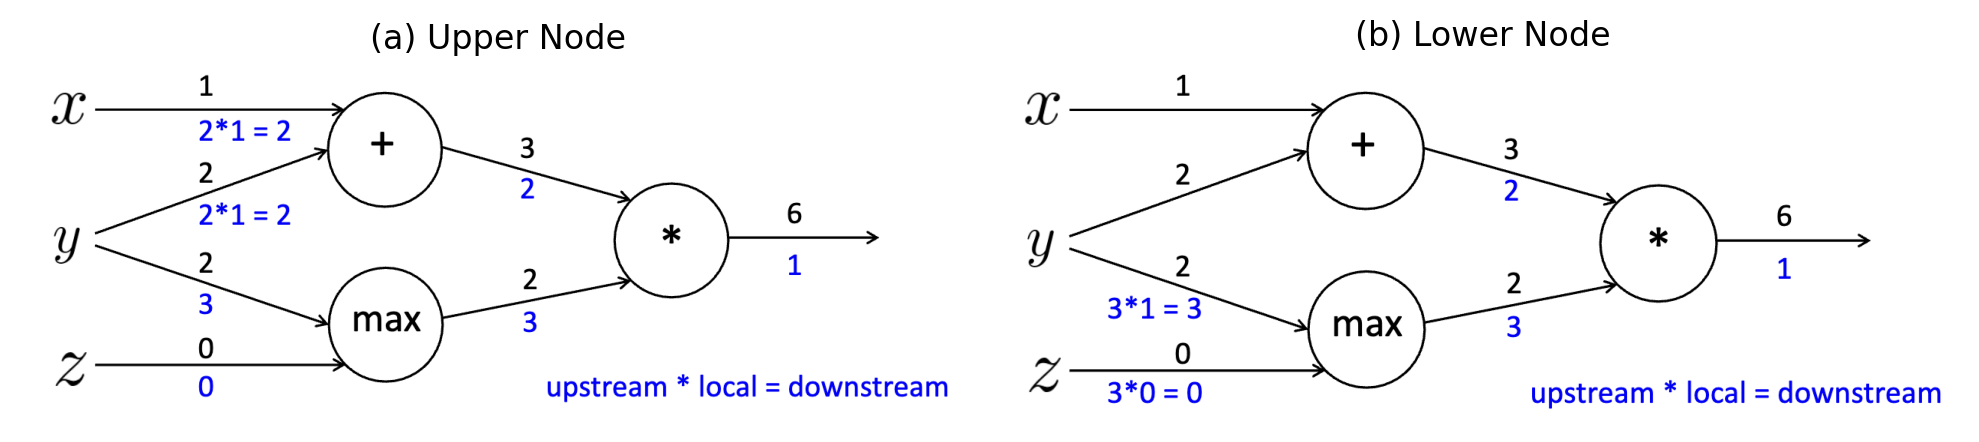

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# 读取图片
img1 = mpimg.imread('images/backpro_compute2.png')
img2 = mpimg.imread('images/backpro_compute1.png')

# 创建并排子图
fig, axs = plt.subplots(1, 2, figsize=(10, 6), dpi=200)

# 显示图片
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('(a) Upper Node', fontsize=12)
axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('(b) Lower Node', fontsize=12)

# 调整第二张图的位置（向上移动）
# 通过set_position调整axes的位置：[left, bottom, width, height]
pos1 = axs[0].get_position()
pos2 = axs[1].get_position()
axs[1].set_position([pos2.x0, pos2.y0 + 0.08, pos2.width, pos2.height])  # y0加大，向上移动

plt.tight_layout()
plt.show()